![Py4Eng](../logo.png)

# Calibration and conformal prediction
## Yoav Ram

In this session we will understand:
- why the largest softmax output is *not* the probability that the prediction is correct
- how to read a **reliability diagram**, and what ECE, NLL and the Brier score each measure
- what a **proper scoring rule** is, and why accuracy is not one
- **temperature scaling**: one parameter, fitted on held-out data, that repairs the probabilities without changing a single prediction
- **split conformal prediction**: a prediction *set* that comes with a finite-sample coverage guarantee, and does not assume the model is any good
- exactly what that guarantee does and does not promise, and what breaks it

## The question

In [transfer learning](transfer.ipynb) we fine-tuned `EfficientNetV2S` on CUB-200-2011 and reached about 77% top-1 accuracy on 200 bird species. We also reported **top-5 accuracy**, which was about 93%: the fraction of images where the true species is among the five most likely.

Both of those numbers are about the model as a whole. Neither tells you anything about *one* image. And in practice, one image is what you have:

> A photograph of a small grey-brown bird comes in. The model says **Barn Swallow, 0.95**. Do you believe it?

(Hold that one. We meet the photograph again in a few cells, and it is a Cliff Swallow.)

This session is one question with three answers, each more honest than the last.

1. **A raw softmax output means nothing.** It is a number in $[0, 1]$ that sums to one across classes, and that is the entire list of properties it is guaranteed to have. It is not the probability that the prediction is correct.
2. **A calibrated probability is a frequency over a population.** If we are willing to spend some held-out data, we can make "0.94" mean "of all the images this model calls 0.94, about 94% are right". That is a real and useful statement — but it is a statement about a population, not about your image.
3. **A conformal prediction set carries a guarantee.** Instead of one species and a number, the model returns a *set* of species, constructed so that the true species is in the set at least 90% of the time — and that holds in finite samples, for any model, without assuming the probabilities are any good.

We will do all three, on the checkpoint we already trained. **This notebook trains nothing.** It loads the fine-tuned model, runs it once to get logits, caches them, and does everything else in NumPy.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

import jax
import jax.numpy as jnp
import keras
print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())

SEED = 23
keras.utils.set_random_seed(SEED)
sns.set(style='white', context='talk')

ALPHA = 0.1      # we will aim for 1 - ALPHA = 90% coverage
NBINS = 15       # bins in the reliability diagram

Keras: 3.15.1 backend: jax cpu


# The data

We need the same held-out split as `transfer.ipynb`: the 5,794 CUB images with `train_test_split.txt` flag 0. We reload the metadata exactly as that notebook does — same four whitespace-separated files, same official split.

The dataset itself must already be downloaded and extracted under `../data/CUB_200_2011`; if it is not, run the download cell in [transfer.ipynb](transfer.ipynb) first.

In [2]:
DATA_DIR = Path('../data')
DATASET_DIR = DATA_DIR / 'CUB_200_2011'
IMG_SIZE = 224

images_df = pd.read_csv(DATASET_DIR / 'images.txt', sep=' ', names=['image_id', 'filename'])
labels_df = pd.read_csv(DATASET_DIR / 'image_class_labels.txt', sep=' ', names=['image_id', 'class_id'])
split_df = pd.read_csv(DATASET_DIR / 'train_test_split.txt', sep=' ', names=['image_id', 'is_training'])
classes_df = pd.read_csv(DATASET_DIR / 'classes.txt', sep=' ', names=['class_id', 'class_name'])

metadata = images_df.merge(labels_df, on='image_id').merge(split_df, on='image_id')
nclasses = len(classes_df)
species = classes_df.class_name.str.split('.').str[1].str.replace('_', ' ').to_numpy()

held_out_idx = np.flatnonzero(~metadata.is_training.to_numpy().astype(bool))
print('{:,} images, {} species, {:,} held out'.format(len(metadata), nclasses, len(held_out_idx)))

11,788 images, 200 species, 5,794 held out


We also want the pixels, because a large part of the payoff of this session is *looking at the birds the model is unsure about*. This is the same cache-or-decode cell as `transfer.ipynb`, and it reads the same `../data/cub_images_224.npy` file — `mmap_mode='r'` maps it instead of reading it, so nothing is copied into memory until we index it.

In [3]:
IMAGES_CACHE = DATA_DIR / 'cub_images_224.npy'

if IMAGES_CACHE.exists():
    images = np.load(IMAGES_CACHE, mmap_mode='r')
    print('Loaded cached array', images.shape, images.dtype)
else:
    paths = [DATASET_DIR / 'images' / filename for filename in metadata.filename]
    images = np.empty((len(paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    t0 = time.time()
    for i, path in enumerate(paths):
        with Image.open(path) as image:
            image = image.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        images[i] = np.asarray(image, dtype=np.uint8)
    np.save(IMAGES_CACHE, images)
    images = np.load(IMAGES_CACHE, mmap_mode='r')
    print('Decoded {:,} images in {:.0f}s'.format(len(paths), time.time() - t0), images.shape)

Loaded cached array (11788, 224, 224, 3) uint8


# The thing we need is upstream of the softmax

Here is the first real idea in the notebook, and it is a detail of plumbing that changes everything downstream.

The `species` layer of our fine-tuned model was built as `Dense(nclasses, activation='softmax')`. So `model.predict` hands back *probabilities*: the softmax has already been applied and thrown the raw numbers away. But every method in this session — temperature scaling most obviously — operates on the **logits**, the pre-softmax scores. Rescaling probabilities is not the same operation as rescaling logits and then applying the softmax, and doing the first when you meant the second is a silent bug.

Keras lets us change a layer's activation on a loaded model:

```python
model.get_layer('species').activation = keras.activations.linear
```

This affects *inference only*. The weights are untouched, the checkpoint on disk is untouched, and `transfer.ipynb` is unaffected. We have not modified the model; we have stopped hiding part of its output.

The logits themselves are expensive to produce — about 29,000 `EfficientNetV2S` forward passes, since we need the clean pass, three noise levels (for §6), and the linear probe (for the exercises). That took **74 seconds on an RTX A4000**, and would take hours on a CPU. So we follow the checkpoint idiom used throughout this course: compute once, cache to disk, and load from the cache on every subsequent run.

> ⚠️ The next cell takes the `else` branch only if `../data/cub_effnetv2s_logits.npz` is missing, and that branch needs a GPU. Everything after it is NumPy and runs on a laptop in seconds.

In [4]:
LOGITS_CACHE = DATA_DIR / 'cub_effnetv2s_logits.npz'
NOISE_SIGMAS = (8, 16, 32)

if LOGITS_CACHE.exists():
    cache = np.load(LOGITS_CACHE)
    print('Loaded cached logits:', ', '.join(sorted(cache.files)))
else:
    X = np.asarray(images[held_out_idx])

    finetune = keras.models.load_model('../data/cub_effnetv2s_finetune.keras')
    finetune.get_layer('species').activation = keras.activations.linear

    # the probe classifies backbone embeddings, so it needs the frozen backbone in front of it
    probe = keras.models.load_model('../data/cub_effnetv2s_probe.keras')
    probe.get_layer('species').activation = keras.activations.linear
    backbone = keras.applications.EfficientNetV2S(
        weights='imagenet', include_top=False, pooling='avg',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )

    def logits_for(model, X, sigma=0.0, chunk=512):
        """Pre-softmax scores, optionally after adding Gaussian noise to the raw uint8 pixels."""
        rng = np.random.default_rng(SEED)
        out = []
        for i in range(0, len(X), chunk):
            batch = X[i:i + chunk].astype('float32')
            if sigma:
                # noise goes on the 0-255 pixels, *before* EfficientNet's internal rescaling
                batch = np.clip(batch + sigma * rng.standard_normal(batch.shape, dtype='float32'), 0, 255)
            out.append(model.predict(batch, batch_size=64, verbose=0))
        return np.concatenate(out).astype('float32')

    t0 = time.time()
    cache = {
        'labels': (metadata.class_id.to_numpy()[held_out_idx] - 1).astype('int32'),
        'image_ids': metadata.image_id.to_numpy()[held_out_idx].astype('int32'),
        'finetune': logits_for(finetune, X),
        'probe': probe.predict(logits_for(backbone, X), batch_size=256, verbose=0).astype('float32'),
    }
    for sigma in NOISE_SIGMAS:
        cache['finetune_noise{:02d}'.format(sigma)] = logits_for(finetune, X, sigma=sigma)
    np.savez_compressed(LOGITS_CACHE, **cache)
    print('Cached {:,} forward passes in {:.0f}s'.format(5 * len(X), time.time() - t0))

Loaded cached logits: finetune, finetune_noise08, finetune_noise16, finetune_noise32, image_ids, labels, probe


Unpack the cache. `labels` are 0-based class indices and `image_ids` are CUB image ids, which we turn into row numbers in the `images` array so that we can show the picture behind any row of logits.

In [5]:
labels = cache['labels']
logits = cache['finetune']
n = len(labels)

row_of_image_id = pd.Series(np.arange(len(metadata)), index=metadata.image_id)
picture = row_of_image_id[cache['image_ids']].to_numpy()   # row i of the logits <-> images[picture[i]]

print('{:,} held-out images, logits {}'.format(n, logits.shape))

5,794 held-out images, logits (5794, 200)


# Splitting the held-out set

Everything below is paid for in held-out data. We are going to *fit* things — a temperature, a quantile — and we cannot then evaluate them on the same images, or we will be reading our own homework. So we cut the 5,794 held-out images in two: a **calibration** half to fit on, and a **validation** half to measure on.

The split is **random**, not stratified by species. That is deliberate, and it is the assumption the whole second half of this notebook rests on. Conformal prediction requires the calibration data and the data you later predict on to be **exchangeable** — informally, that any ordering of them is equally likely, so a fresh image is statistically interchangeable with the calibration images. A uniformly random split of one pool gives exactly that, by construction. A stratified split does not: it fixes the number of images per species, which a genuinely fresh sample would not respect.

**One honest caveat.** `transfer.ipynb` plotted `val_accuracy` on these same 5,794 images while training, so they are not perfectly untouched. There was no early stopping and no model selection based on them — the schedule was fixed in advance and ran to the end — so the leakage is weak. But it is not zero, and you should hear it said rather than discover it yourself. In a study you were going to publish, calibration data would be a third split, held back from the start.

In [6]:
perm = np.random.default_rng(SEED).permutation(n)
calibration, validation = perm[: n // 2], perm[n // 2:]

print('calibration {:,} images, validation {:,} images'.format(len(calibration), len(validation)))

calibration 2,897 images, validation 2,897 images


# The softmax is not a probability

Let us just look. We take the softmax of the logits, read off the predicted species and the probability the model attached to it, and compare the average of those probabilities to how often the model is actually right.

We write the softmax out by hand rather than importing one. Subtracting the row maximum changes nothing mathematically — the same constant cancels from numerator and denominator — but it keeps `exp` away from overflow. The `T` argument is temperature; ignore it for now, it defaults to 1 and does nothing.

In [7]:
def probabilities(logits, T=1.0):
    z = np.asarray(logits) / T
    z = z - z.max(axis=1, keepdims=True)    # cancels out; keeps exp() in range
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

P = probabilities(logits)
y = labels[validation]
p_validation = P[validation]

confidence = p_validation.max(axis=1)
prediction = p_validation.argmax(axis=1)
correct = prediction == y

print('accuracy               {:.1%}'.format(correct.mean()))
print('mean top probability   {:.1%}'.format(confidence.mean()))

accuracy               76.5%
mean top probability   55.8%


There is the gap, and it is 21 percentage points wide.

Pause on the direction, because it is not the one the literature will have led you to expect. The famous result here is [Guo et al. 2017](https://arxiv.org/abs/1706.04599), *On Calibration of Modern Neural Networks*, and its headline is that modern networks are **overconfident** — they say 0.99 and are right 0.9 of the time. Our model is the other way around: it says 0.56 and is right 0.76 of the time. It is **underconfident**.

We will come back to *why* in §3, and the answer turns out to be sitting in `transfer.ipynb`. For now the point is the one the section title makes: the number the softmax produces is not the probability of being correct. It is not even reliably wrong in a fixed direction. "Neural networks are overconfident" is an empirical claim about a *training recipe*, not a law of nature, and the only way to know what your model does is to measure it.

Here is the whole distribution.

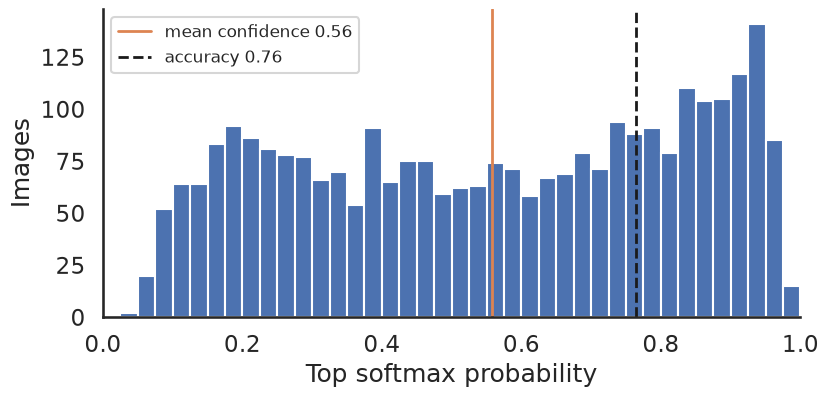

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(confidence, bins=40, range=(0, 1), color='C0')
ax.axvline(confidence.mean(), c='C1', lw=2, label='mean confidence {:.2f}'.format(confidence.mean()))
ax.axvline(correct.mean(), c='k', ls='--', lw=2, label='accuracy {:.2f}'.format(correct.mean()))
ax.set(xlabel='Top softmax probability', ylabel='Images', xlim=(0, 1))
ax.legend(fontsize=12)
sns.despine()

The mass is spread across the whole interval. A model of this accuracy that was also *calibrated* would pile up near the right-hand edge; this one hedges everywhere.

Now the mistakes. If the top probability were a probability of being correct, then among the images where the model reports more than 0.9 we should see roughly one error in ten. Let us find the errors it was most sure about.

682 errors on the validation half
358 images above confidence 0.9, of which 6 are wrong: 1.7%
a calibrated model would be wrong about 10% of the time up there


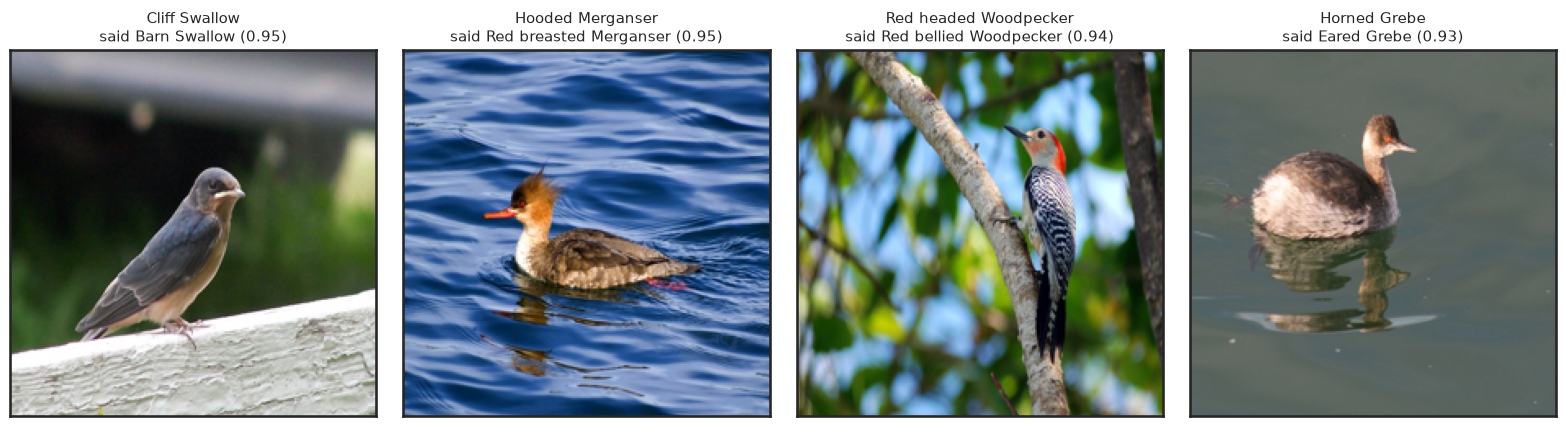

In [9]:
errors = np.flatnonzero(~correct)
most_confident_errors = errors[np.argsort(-confidence[errors])][:4]

confident = confidence > 0.9
print('{:,} errors on the validation half'.format(len(errors)))
print('{:,} images above confidence 0.9, of which {} are wrong: {:.1%}'.format(
    confident.sum(), (confident & ~correct).sum(), (~correct[confident]).mean()))
print('a calibrated model would be wrong about 10% of the time up there')

fig, axes = plt.subplots(1, 4, figsize=(16, 4.6))
for ax, i in zip(axes, most_confident_errors):
    ax.imshow(images[picture[validation[i]]])
    ax.set(xticks=[], yticks=[])
    ax.set_title('{}\nsaid {} ({:.2f})'.format(species[y[i]], species[prediction[i]], confidence[i]),
                 fontsize=11)
fig.tight_layout()

Two things to read off this figure.

First, the *numbers above the figure*. Of the 358 images it calls more than 0.9, exactly 6 are wrong — 1.7%, not 10% — it is far better up there than it claims to be, which is the underconfidence again. And to find four confident errors at all we had to look above 0.93 rather than above 0.99, because this model almost never says 0.99 about anything.

Second, the *content*. Every one of these is a confusion between two species in the same genus or family — the kind of pair a birdwatcher argues about. The model is not lost; it is making a fine distinction and losing. That is a useful thing to know, and notice that neither the accuracy nor the confidence number told us. A **set** of two swallows would have told us.

Third, and worth a moment: look closely at the middle two before you accept that they are errors. CUB's labels are crowd-sourced on a problem where the classes are genuinely hard, and fine-grained datasets carry real label noise. Some fraction of any error list is the *dataset* being wrong rather than the model, and a single accuracy number cannot tell you which.

This phenomenon has a name: **accuracy/confidence decoupling**. Cross-entropy training optimizes the model to put the true class on top. It does not optimize the *value* it reports, except indirectly, and nothing in the training loop ever checks that those values behave like frequencies. A model that memorized its 5,994 training images completely — and ours did, its training accuracy reached 1.0 — has seen exactly zero examples of "an image I am 60% sure about", because by the end of training it was sure about everything it had seen.

# Reliability diagrams and proper scoring rules

Let us make "calibrated" precise.

> A model is **calibrated** if, among the predictions it makes with confidence $\approx p$, a fraction $\approx p$ are correct.

Formally, writing $\hat{p}$ for the top probability and $\hat{y}$ for the predicted class,
$$
P\left(\hat{y} = y \mid \hat{p} = p\right) = p \quad \text{for all } p \in [0, 1] .
$$

We cannot check that condition at a single $p$ — no two images get exactly the same probability — so we bin. Sort the predictions into 15 equal-width confidence bins; in each bin, compare the mean confidence to the fraction correct. Plotting one against the other gives a **reliability diagram**, and a calibrated model lies on the diagonal.

Note what this definition covers and what it does not. It is a statement about *top-label* calibration, the number attached to the winning class. It says nothing about the other 199 probabilities.

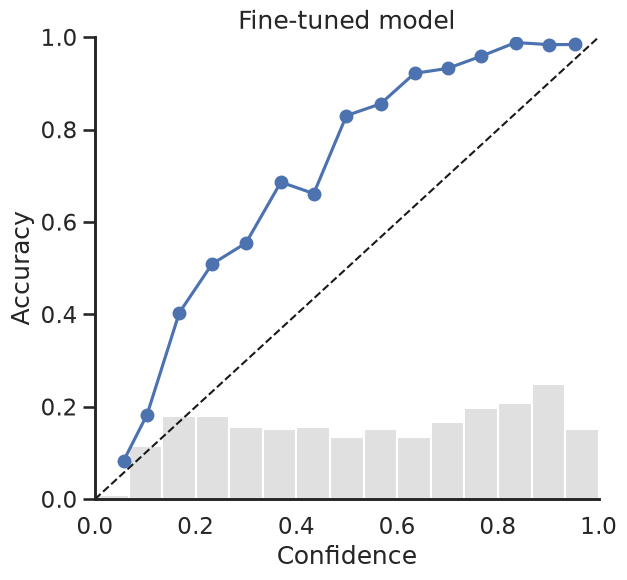

In [10]:
def reliability(prob, y, nbins=NBINS):
    """Bin predictions by confidence and compare mean confidence to accuracy in each bin."""
    confidence, prediction = prob.max(axis=1), prob.argmax(axis=1)
    hit = (prediction == y).astype(float)
    edges = np.linspace(0, 1, nbins + 1)
    which = np.clip(np.digitize(confidence, edges[1:-1]), 0, nbins - 1)
    rows = [(edges[b], edges[b + 1], (which == b).sum(),
             confidence[which == b].mean() if (which == b).any() else np.nan,
             hit[which == b].mean() if (which == b).any() else np.nan)
            for b in range(nbins)]
    return pd.DataFrame(rows, columns=['low', 'high', 'count', 'confidence', 'accuracy'])

def plot_reliability(bins, ax, title=None):
    counts = ax.twinx()
    counts.bar((bins.low + bins.high) / 2, bins['count'], width=(bins.high - bins.low).mean(),
               color='0.88', zorder=0)
    counts.set(ylim=(0, bins['count'].max() * 4), yticks=[])
    counts.grid(False)
    ax.set_zorder(counts.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.plot([0, 1], [0, 1], ls='--', c='k', lw=1.5)
    ax.plot(bins.confidence, bins.accuracy, 'o-', c='C0')
    ax.set(xlabel='Confidence', ylabel='Accuracy', xlim=(0, 1), ylim=(0, 1), title=title)

fig, ax = plt.subplots(figsize=(6.5, 6))
plot_reliability(reliability(p_validation, y), ax, title='Fine-tuned model')
sns.despine(right=True)

The grey bars behind the curve are the number of images in each bin, and they matter: a bin holding 12 images and a bin holding 300 are drawn the same width, and it is easy to over-read the ones that are nearly empty.

The curve sits **above** the diagonal almost everywhere. Above the diagonal means accuracy exceeds confidence — underconfidence. Below the diagonal is overconfidence, which is what Guo et al. found and what you will usually see; we happen to have the other one.

To compress the picture into a number, take the average vertical gap between the curve and the diagonal, weighting each bin by how many images are in it. That is the **Expected Calibration Error**:
$$
\text{ECE} = \sum_{b=1}^{B} \frac{n_b}{n} \left| \text{accuracy}(b) - \text{confidence}(b) \right| .
$$

One caveat, once: ECE depends on the binning. Change the number of bins, or use equal-mass bins instead of equal-width ones, and the number moves. Treat it as a summary for comparing models measured the same way, not as a quantity with an objective value.

In [11]:
def ece(prob, y, nbins=NBINS):
    bins = reliability(prob, y, nbins)
    weight = bins['count'] / bins['count'].sum()
    return float(np.nansum(weight * (bins.accuracy - bins.confidence).abs()))

print('ECE {:.4f}'.format(ece(p_validation, y)))

ECE 0.2070


## Proper scoring rules

ECE throws away everything except the top probability. Two other losses use the whole vector, and both should be familiar.

The **negative log-likelihood** is the average surprise at the true class,
$$
\text{NLL} = -\frac{1}{n}\sum_{i=1}^{n} \log p(y_i \mid x_i) ,
$$
which is the same quantity we minimized in [maximum likelihood estimation](mle.ipynb), and — under a different name, categorical cross-entropy — the loss the model was actually trained on. The **Brier score** is the squared error between the probability vector and the one-hot truth,
$$
\text{Brier} = \frac{1}{n}\sum_{i=1}^{n} \sum_{k=1}^{K} \left(p(k \mid x_i) - \mathbb{1}[y_i = k]\right)^2 .
$$

In [12]:
def nll(prob, y):
    return float(-np.log(prob[np.arange(len(y)), y] + 1e-12).mean())

def brier(prob, y):
    onehot = np.zeros_like(prob)
    onehot[np.arange(len(y)), y] = 1
    return float(((prob - onehot) ** 2).sum(axis=1).mean())

print('NLL   {:.4f}'.format(nll(p_validation, y)))
print('Brier {:.4f}'.format(brier(p_validation, y)))

NLL   1.1370
Brier 0.3842


Both are **proper scoring rules**, and that is the property worth carrying away.

> A scoring rule is **proper** if its expected value is minimized by reporting your true beliefs. There is no probability vector you could report that would score better, in expectation, than the true one.

That is a strong statement: a proper scoring rule cannot be gamed. Whatever you believe, your best strategy under NLL or Brier is to say exactly that.

**Accuracy is not a proper scoring rule.** It does not even look at the probabilities, only at the argmax. Report 0.51 for the correct class or report 0.999 and accuracy scores you identically. Log loss separates those two hardest precisely where it matters — when you are confidently *wrong*, $-\log p$ goes to infinity while accuracy just records one more error.

This is why "my model is 77% accurate" and "my model's probabilities are trustworthy" are separate claims needing separate evidence, and it is why the rest of this session exists.

# Temperature scaling

The repair is almost insultingly simple. Divide every logit by one positive number $T$ before the softmax:
$$
p_k(T) = \frac{\exp(z_k / T)}{\sum_{j} \exp(z_j / T)} .
$$

$T > 1$ flattens the distribution towards uniform and makes the model less confident; $T < 1$ sharpens it. $T = 1$ is the model as trained. One scalar, for the entire 200-way output, for every image.

We fit $T$ by minimizing NLL **on the calibration half only**. Two notes on how:

- We optimize $\log T$ rather than $T$, so that $T = e^{\log T}$ stays positive without our having to constrain anything.
- We use `jax.grad` and an explicit gradient-descent loop, exactly as in [JAX](jax.ipynb) and [feed-forward networks](FFN.ipynb). This is a reminder worth having: "fitting a model" and "deep learning" are not synonyms. One parameter, a hand-written loop, no optimizer object, no Keras.

In [13]:
def nll_temperature(log_T, logits, y):
    logp = jax.nn.log_softmax(logits / jnp.exp(log_T), axis=1)
    return -jnp.mean(logp[jnp.arange(len(y)), y])

nll_grad = jax.jit(jax.grad(nll_temperature))

def fit_temperature(logits, y, eta=0.1, steps=300, verbose=False):
    log_T = 0.0                                   # start at T = 1, the model as trained
    for t in range(1, steps + 1):
        log_T -= eta * nll_grad(log_T, logits, y)
        if verbose and t % 50 == 0:
            print('  step {:3d}: T = {:.4f}, NLL = {:.4f}'.format(
                t, np.exp(log_T), nll_temperature(log_T, logits, y)))
    return float(np.exp(log_T))

T = fit_temperature(logits[calibration], labels[calibration], verbose=True)
print('fitted T = {:.4f}'.format(T))

  step  50: T = 0.6563, NLL = 0.9565
  step 100: T = 0.6563, NLL = 0.9565
  step 150: T = 0.6563, NLL = 0.9565
  step 200: T = 0.6563, NLL = 0.9565


  step 250: T = 0.6563, NLL = 0.9565
  step 300: T = 0.6563, NLL = 0.9565
fitted T = 0.6563


$T = 0.66$, which is **less than one**. The fit is sharpening the distribution, not flattening it — confirming from the other side what §1 showed: this model is underconfident.

Why? The answer is in `transfer.ipynb`, in the fourth of the four decisions that protected the pretrained weights: **label smoothing**. The fine-tune was trained with `CategoricalCrossentropy(label_smoothing=0.1)`, so instead of asking for probability 1.0 on the correct species it asked for 0.9, with the remaining 0.1 spread over the other 199. A model trained to a ceiling of 0.9 does not learn to say 0.99, and on harder validation images it lands much lower still.

Label smoothing is a *regularizer*; it was chosen in that notebook to stop the network from driving its logits to extremes and overfitting a fine-grained problem. It worked. But it also means the probabilities coming out are systematically compressed, and temperature scaling is now partly undoing a distortion we deliberately introduced.

This is an inference, not a controlled experiment — we did not retrain anything — but there is supporting evidence close at hand. The linear probe from the same session was trained on the same data with the *same* backbone and **no** label smoothing, and Exercise 2 asks you to fit its temperature. It comes out near 1.

Now the key property.

In [14]:
p_calibrated = probabilities(logits, T)[validation]

print('accuracy before {:.4%}'.format(correct.mean()))
print('accuracy after  {:.4%}'.format((p_calibrated.argmax(axis=1) == y).mean()))
assert np.array_equal(p_calibrated.argmax(axis=1), prediction), 'temperature changed a prediction'
print('every single prediction is unchanged')

accuracy before 76.4584%
accuracy after  76.4584%
every single prediction is unchanged


Not approximately the same — **identical**, on every one of the 2,897 images.

The reason is one line of algebra. Dividing all logits by a positive scalar is a monotone transformation, so it cannot reorder them; the softmax is monotone too; so the argmax is fixed. Temperature scaling cannot change a single decision the model makes, at any temperature.

That also tells you what temperature scaling *cannot* do: it cannot fix a model. It only changes how loudly the model asserts things.

Here are the two reliability diagrams side by side.

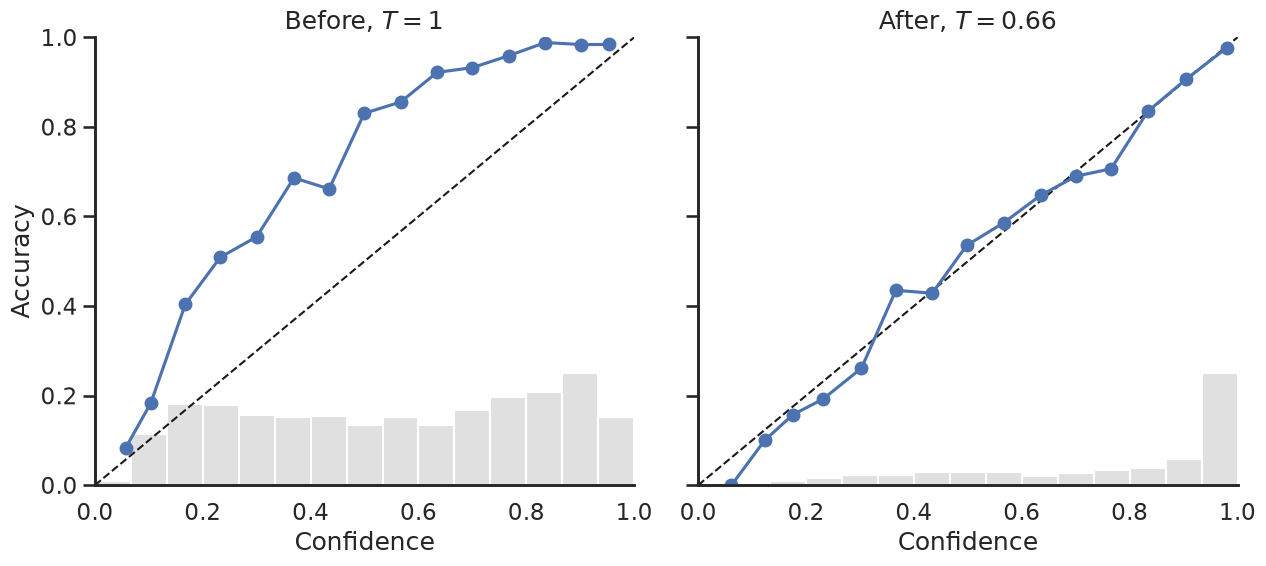

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
plot_reliability(reliability(p_validation, y), axes[0], title='Before, $T = 1$')
plot_reliability(reliability(p_calibrated, y), axes[1], title='After, $T = {:.2f}$'.format(T))
axes[1].set(ylabel=None)
fig.tight_layout()
sns.despine(right=True)

In [16]:
comparison = pd.DataFrame({
    'Before (T = 1)': {'accuracy': correct.mean(), 'mean confidence': confidence.mean(),
                       'NLL': nll(p_validation, y), 'Brier': brier(p_validation, y),
                       'ECE': ece(p_validation, y)},
    'After (T = {:.2f})'.format(T): {'accuracy': (p_calibrated.argmax(axis=1) == y).mean(),
                                     'mean confidence': p_calibrated.max(axis=1).mean(),
                                     'NLL': nll(p_calibrated, y), 'Brier': brier(p_calibrated, y),
                                     'ECE': ece(p_calibrated, y)},
})
print(comparison.to_string(float_format='{:.4f}'.format))

                 Before (T = 1)  After (T = 0.66)
accuracy                 0.7646            0.7646
mean confidence          0.5576            0.7673
NLL                      1.1370            0.9287
Brier                    0.3842            0.3253
ECE                      0.2070            0.0149


The curve has come down onto the diagonal, the grey bars have moved to the right (the model now says 0.9 about a lot of images, and is right about 90% of them), ECE has fallen from 0.21 to 0.015, NLL and Brier have both improved, and accuracy has not moved at all. One parameter.

## Calibration is not free

It is tempting to summarize that table as "free". Resist it, and be precise about what was and was not free.

What is free is **accuracy**: no prediction changed, so nothing was traded away on the decision side.

What it **cost is data**. We spent 2,897 labelled held-out images — images that could have been training data — to fit one scalar. In this notebook they were lying around; in a real project that is a real budget. And the price has a second half that does not appear on any table: those images have to be **exchangeable with whatever the model meets in deployment**. A temperature fitted on clean studio photographs of birds is a statement about clean studio photographs of birds.

Every method in this notebook is bought with held-out data on those terms. §6 is what happens when only the first half of the price gets paid.

# From top-5 to prediction sets

Recall the other number from `transfer.ipynb`: top-5 accuracy, 93%. Take the five most likely species, and 93% of the time the truth is among them.

Why five?

Nothing in the data chose 5. It is a convention inherited from the ImageNet competition. And it has two real problems. It **ignores the image**: the bird the model has nailed and the bird it cannot tell from three other sparrows both get exactly five candidates. And it **carries no guarantee**: 93% is a number we measured afterwards, not a level we asked for and were given.

What we want instead is a rule that takes an image and returns a **set** of species, small when the model is sure and large when it is not, such that
$$
P\left(Y \in C(X)\right) \geq 1 - \alpha
$$
for a coverage level $1-\alpha$ we choose in advance. **Split conformal prediction** does exactly this, in about four lines, and — this is the surprising part — it works for *any* model, with no assumption that its probabilities are good.

The recipe:

1. On the calibration half, score each image by how much probability the model gave to the **true** class: $s_i = 1 - p(y_i \mid x_i)$. A small score means the model was right and confident; a large score means the truth was buried.
2. Take $\hat{q}$ to be a high quantile of those scores — the level of "how badly wrong this model usually gets to be".
3. For a new image, keep every class whose probability is at least $1 - \hat{q}$:
$$
C(x) = \left\{ k : p(k \mid x) \geq 1 - \hat{q} \right\} .
$$

Step 2 needs care, and the care is the whole reason the guarantee is exact. We do not take the $(1-\alpha)$ quantile. We take the $\lceil (m+1)(1-\alpha) \rceil$-th smallest of the $m$ calibration scores. The $+1$ accounts for the new image itself: under exchangeability we are asking where a fresh score would fall among $m+1$ scores, not among $m$. Getting this wrong loses a little coverage on small calibration sets and turns a finite-sample statement into an asymptotic one.

In [17]:
def conformal_quantile(prob, y, alpha=ALPHA):
    """The threshold q-hat, from the conformity scores of a calibration set."""
    scores = 1 - prob[np.arange(len(y)), y]
    m = len(scores)
    k = int(np.ceil((m + 1) * (1 - alpha)))       # note the (m + 1), not m
    assert k <= m, 'alpha is too small for {:,} calibration points'.format(m)
    return float(np.sort(scores)[k - 1])

def prediction_sets(prob, qhat):
    return prob >= 1 - qhat

def coverage(sets, y):
    return float(sets[np.arange(len(y)), y].mean())

p_cal = probabilities(logits, T)[calibration]
qhat = conformal_quantile(p_cal, labels[calibration])
print('q-hat = {:.4f}, so we keep every species with probability >= {:.4f}'.format(qhat, 1 - qhat))

q-hat = 0.9560, so we keep every species with probability >= 0.0440


That threshold is startlingly low: any species the model gives more than a 4.4% chance goes into the set. Now measure on the validation half, which had no part in choosing $\hat{q}$.

In [18]:
sets = prediction_sets(probabilities(logits, T)[validation], qhat)
sizes = sets.sum(axis=1)

print('target coverage    {:.1%}'.format(1 - ALPHA))
print('empirical coverage {:.1%}'.format(coverage(sets, y)))

target coverage    90.0%
empirical coverage 90.5%


90.5% against a target of 90%. We asked for a level and we got it, to within half a percentage point, and we did not tune anything to make that happen.

Now the part that top-5 cannot do: the sets have **different sizes**.

mean size 2.06, median 1, largest 8
singletons      50.5%
larger than 5   3.2%


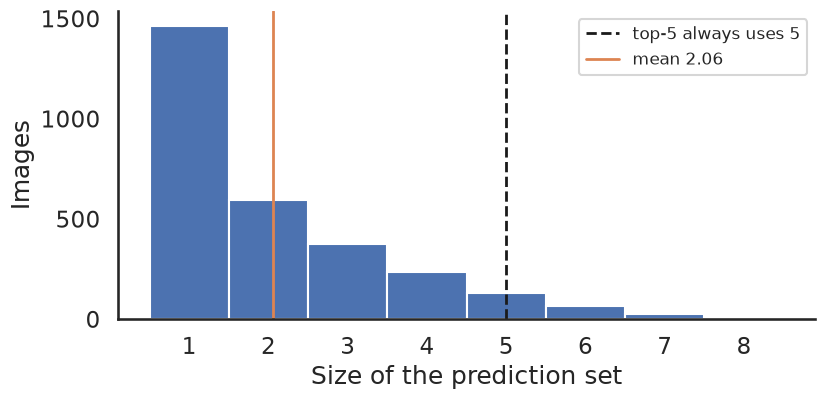

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sizes, bins=np.arange(0.5, sizes.max() + 1.5), color='C0')
ax.axvline(5, c='k', ls='--', lw=2, label='top-5 always uses 5')
ax.axvline(sizes.mean(), c='C1', lw=2, label='mean {:.2f}'.format(sizes.mean()))
ax.set(xlabel='Size of the prediction set', ylabel='Images')
ax.legend(fontsize=12)
sns.despine()

print('mean size {:.2f}, median {:.0f}, largest {}'.format(sizes.mean(), np.median(sizes), sizes.max()))
print('singletons      {:.1%}'.format((sizes == 1).mean()))
print('larger than 5   {:.1%}'.format((sizes > 5).mean()))

Half the images come back with a **single species** and a 90% guarantee attached — five times sharper than top-5, at the same kind of coverage. Only 3% of images need more than five candidates, and those are the ones where top-5 was quietly failing.

The set size is the model's own statement about the difficulty of *that image*. Let us read a few - a singleton, a pair, and the largest set on the validation half. (We pick examples whose set does contain the true species; about one in ten does not, which is exactly what we asked for.)

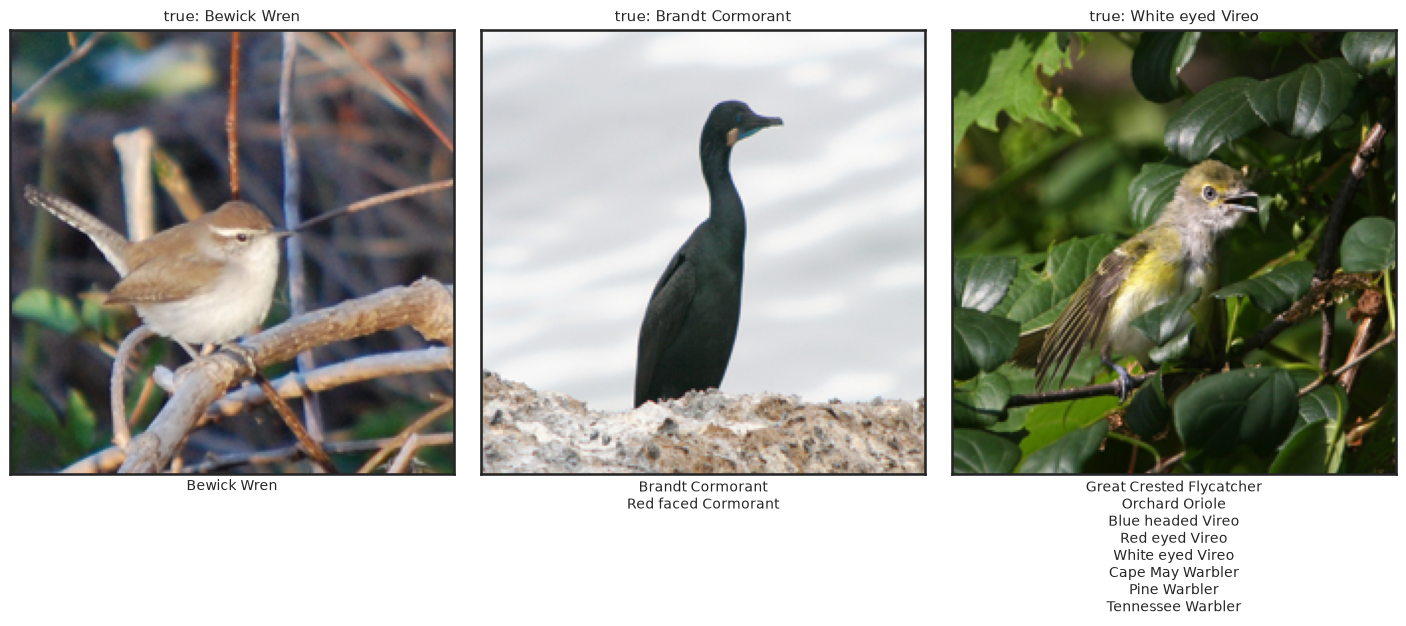

In [20]:
covered = sets[np.arange(len(y)), y]
examples = [np.flatnonzero(covered & (sizes == k))[0] for k in (1, 2, sizes.max())]

fig, axes = plt.subplots(1, len(examples), figsize=(4.8 * len(examples), 6))
for ax, i in zip(axes, examples):
    ax.imshow(images[picture[validation[i]]])
    ax.set(xticks=[], yticks=[], title='true: {}'.format(species[y[i]]))
    ax.title.set_fontsize(11)
    ax.set_xlabel('\n'.join(species[k] for k in np.flatnonzero(sets[i])), fontsize=10)
fig.tight_layout()

This is the payoff of doing this on a fine-grained problem. The sets are not arbitrary — they are sets of *confusable species*. A cormorant comes back as two cormorants; a vireo comes back as a spread of vireos, warblers and orioles, which is a perfectly reasonable thing to be unsure about from a small photograph of a small brown bird in a bush.

## The guarantee did not need the probabilities to be good

One more experiment, and it is the one that shows what "distribution-free" means. Run the whole recipe again on the **uncalibrated** probabilities — the badly miscalibrated ones from §1, before we fitted any temperature.

In [21]:
qhat_raw = conformal_quantile(P[calibration], labels[calibration])
sets_raw = prediction_sets(p_validation, qhat_raw)

print('               q-hat    coverage   mean size   singletons')
for name, q, s in (('calibrated  ', qhat, sets), ('uncalibrated', qhat_raw, sets_raw)):
    print('{}   {:.4f}   {:.1%}      {:.2f}        {:.1%}'.format(
        name, q, coverage(s, y), s.sum(axis=1).mean(), (s.sum(axis=1) == 1).mean()))

               q-hat    coverage   mean size   singletons
calibrated     0.9560   90.5%      2.06        50.5%
uncalibrated   0.9501   90.3%      2.11        39.9%


**Coverage holds either way.** 90.3% against 90.5%, both on target.

That is the point. The conformal guarantee never asked the network's probabilities to be correct. It only used them to *rank* candidate classes, and then calibrated a threshold empirically against real labels. Feed it a terrible probability model and you still get your 90% — you just pay for it in set size, because a worse ranking needs wider sets to catch the truth.

And that is visible here: the mean sizes are close, 2.06 against 2.11, but the fraction of singletons drops from 50.5% to 39.9%. Calibration bought us sharper sets on the easy images, not coverage. Coverage was already guaranteed.

# What the guarantee does not say

Conformal prediction is unusually easy to over-sell, so it is worth being precise about the statement we have actually bought:
$$
P\left(Y \in C(X)\right) \geq 1 - \alpha .
$$

**It is marginal, not conditional.** The probability is over the joint draw of $(X, Y)$ *and* the calibration set — it is an average over everything. It does **not** say that every image is covered with probability 0.9, and it does **not** say that every species is. Our 200 species are almost certainly not covered equally: the easy waterfowl are probably at 97% and some hard sparrow at 70%, averaging to 90%. This is the most common misreading of conformal prediction, and it matters, because "90% of the time" is cold comfort if the 10% is concentrated on one class you care about.

Fixing it properly means **class-conditional** (Mondrian) conformal prediction: a separate $\hat{q}$ per species. We are not doing that here, and the reason is arithmetic — 5,794 held-out images over 200 species is 29 images per species, and half of those are in the calibration half. A 90% quantile of 14 numbers is not an estimate of anything. Conditional guarantees are expensive in data, and this dataset cannot afford them.

**Coverage is not correctness.** A set of eight birds that contains the true species is a *covered* prediction. It is not an identification. The procedure did its job; you still do not know what the bird is. Coverage and usefulness are different axes, which is exactly why we reported the set-size distribution alongside the coverage and why you should never report one without the other.

**It assumes exchangeability.** Everything above rests on the calibration images and the deployment images being draws you could shuffle together without noticing. That is not a mathematical assumption you can check off — it is an empirical claim about the world, it is the one thing in this notebook that can be false, and it fails constantly: cameras change, seasons change, someone starts uploading phone photos instead of DSLR photos. §6 breaks it on purpose.

**A different axis entirely.** Everything here is about *aleatoric*-flavoured uncertainty as expressed by one fixed model: given this network, how sure can we be? It says nothing about **epistemic** uncertainty — how much the model itself would change if we had trained it differently, or on more data. That is the territory of MC dropout, deep ensembles and Bayesian neural networks, which estimate uncertainty by varying the model rather than by calibrating one. They are complementary to this session, not alternatives to it, and they cost several forward passes or several models where conformal prediction costs one.

# When exchangeability fails

Let us break it, in the most boring way possible: add Gaussian noise to the pixels. This is not an adversarial attack, not a different dataset, not even a different camera — just slightly worse photographs, $\sigma \in \{8, 16, 32\}$ on a 0-255 scale. Judge the severity for yourself.

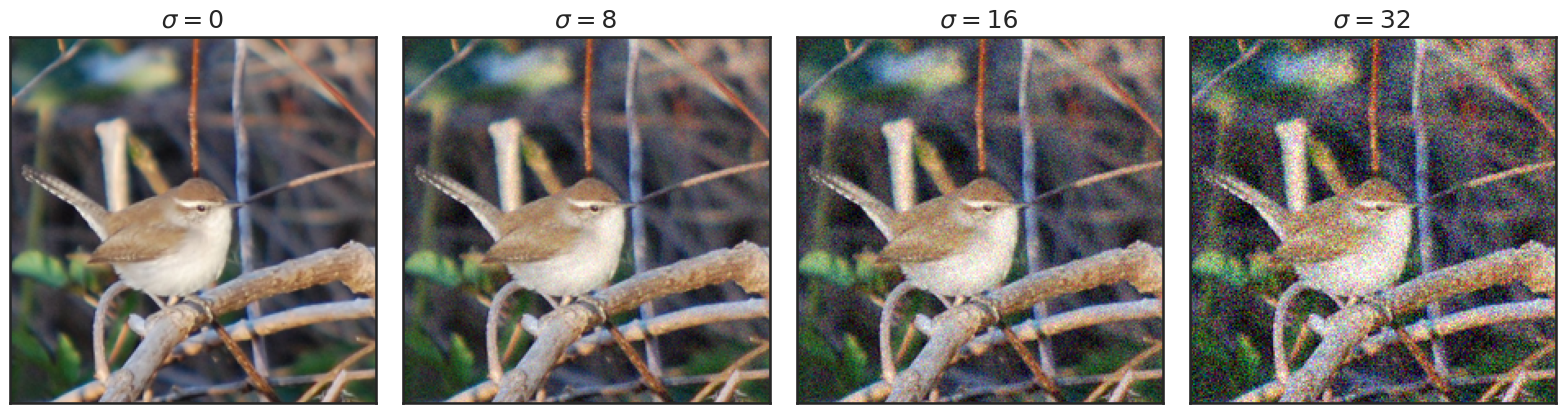

In [22]:
bird = picture[validation[examples[0]]]
noise = np.random.default_rng(SEED).standard_normal((IMG_SIZE, IMG_SIZE, 3))

fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, sigma in zip(axes, (0,) + NOISE_SIGMAS):
    ax.imshow(np.clip(images[bird] + sigma * noise, 0, 255).astype('uint8'))
    ax.set(xticks=[], yticks=[], title='$\\sigma = {}$'.format(sigma))
fig.tight_layout()

At $\sigma = 8$ you have to look for it, and at $\sigma = 32$ the bird is still perfectly identifiable to a human. Keep that in mind while reading the next table.

The logits for all three severities are already in the cache. Crucially, we now do what a deployed system does: we **keep** the temperature and the $\hat{q}$ that we fitted on clean data, and apply them to shifted images. Nothing is refitted. The model has not been told that anything changed — that is the entire point, because in the field nobody tells you.

In [23]:
rows = []
for sigma in (0,) + NOISE_SIGMAS:
    key = 'finetune' if sigma == 0 else 'finetune_noise{:02d}'.format(sigma)
    prob = probabilities(cache[key], T)[validation]       # clean-fitted T
    s = prediction_sets(prob, qhat)                       # clean-fitted q-hat
    rows.append({'sigma': sigma,
                 'accuracy': (prob.argmax(axis=1) == y).mean(),
                 'mean confidence': prob.max(axis=1).mean(),
                 'ECE': ece(prob, y),
                 'coverage': coverage(s, y),
                 'mean set size': s.sum(axis=1).mean()})

shift = pd.DataFrame(rows).set_index('sigma')
print(shift.to_string(float_format='{:.3f}'.format))

       accuracy  mean confidence   ECE  coverage  mean set size
sigma                                                          
0         0.765            0.767 0.015     0.905          2.062
8         0.737            0.748 0.021     0.883          2.173
16        0.690            0.708 0.031     0.851          2.380
32        0.568            0.620 0.053     0.760          2.782


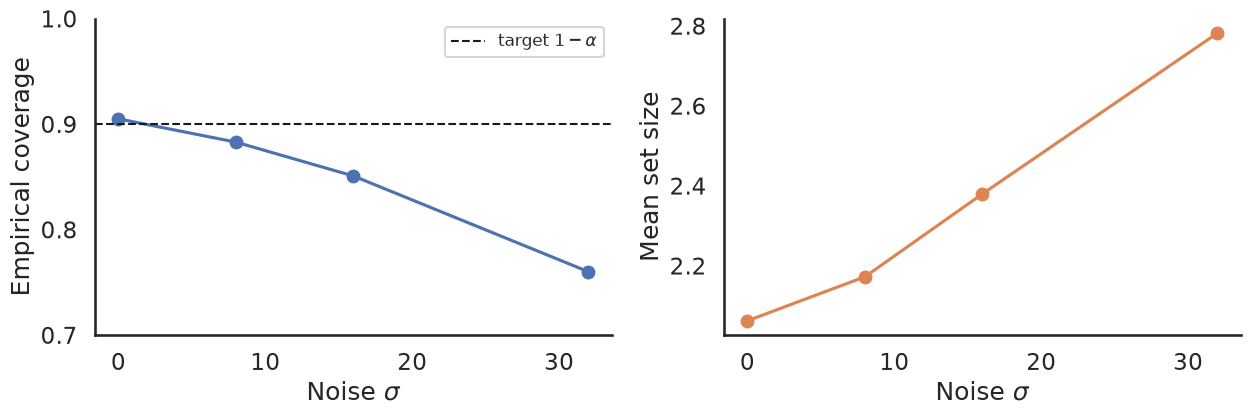

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(shift.index, shift.coverage, 'o-')
ax.axhline(1 - ALPHA, c='k', ls='--', lw=1.5, label='target $1 - \\alpha$')
ax.set(xlabel='Noise $\\sigma$', ylabel='Empirical coverage', ylim=(0.7, 1.0))
ax.legend(fontsize=12)

ax = axes[1]
ax.plot(shift.index, shift['mean set size'], 'o-', c='C1')
ax.set(xlabel='Noise $\\sigma$', ylabel='Mean set size')

fig.tight_layout()
sns.despine()

Coverage falls away from the target immediately and keeps going: 90.5%, 88.3%, 85.1%, 76.0%. At $\sigma = 32$ we promised 90% and delivered 76%.

Read the two panels together, because the second explains the first. The sets *do* get bigger — 2.06 to 2.78 — because the noisy images get flatter probability vectors, so more species clear the threshold. The model is genuinely less sure and says so. But it does not get bigger *fast enough*, because $\hat{q}$ is frozen. The threshold was chosen to match how wrong this model gets on clean birds, and on noisy birds it is wrong in ways that threshold never saw. Meanwhile accuracy has fallen from 76.5% to 56.8%, so there is much more to cover and no more room to cover it.

The temperature does not survive either: ECE climbs from 0.015 to 0.053 under the clean-fitted $T$. The compression that $T = 0.66$ was correcting is not the same compression the noisy images produce.

Say clearly what has happened here, because it is easy to say it wrong: **the method is not broken.** Conformal prediction made a conditional promise — 90% coverage *provided calibration and deployment data are exchangeable* — and we violated the condition. A guarantee with a violated precondition is not a failed guarantee; it is an inapplicable one. That distinction matters in practice, because it tells you what to go and fix.

# Recalibrating under shift

So fix it. If the problem is that $\hat{q}$ and $T$ describe the wrong distribution, get some data from the right one.

We take **500 labelled images from the shifted distribution** — drawn from the calibration half, at $\sigma = 16$ — and refit both the temperature and the quantile on those 500 alone. Nothing else changes: same model, same weights, same recipe.

In [25]:
shift_sample = np.random.default_rng(SEED).choice(calibration, size=500, replace=False)
logits_16 = cache['finetune_noise16']

T_16 = fit_temperature(logits_16[shift_sample], labels[shift_sample])
p_16 = probabilities(logits_16, T_16)
qhat_16 = conformal_quantile(p_16[shift_sample], labels[shift_sample])

print('temperature  {:.3f}  ->  {:.3f}'.format(T, T_16))
print('q-hat        {:.4f}  ->  {:.4f}'.format(qhat, qhat_16))

temperature  0.656  ->  0.679
q-hat        0.9560  ->  0.9839


In [26]:
sets_16 = prediction_sets(p_16[validation], qhat_16)
before = shift.loc[16]

print('at sigma = 16, evaluated on the validation half')
print('                clean-fitted   refitted on 500')
print('coverage           {:.1%}          {:.1%}'.format(before.coverage, coverage(sets_16, y)))
print('mean set size      {:.2f}            {:.2f}'.format(before['mean set size'], sets_16.sum(axis=1).mean()))
print('ECE                {:.3f}           {:.3f}'.format(before.ECE, ece(p_16[validation], y)))

at sigma = 16, evaluated on the validation half
                clean-fitted   refitted on 500
coverage           85.1%          90.9%
mean set size      2.38            4.35
ECE                0.031           0.018


Coverage comes back: 85.1% to 90.9%, on target again. And look at the price — the mean set size nearly doubles, 2.38 to 4.35.

That is the honest outcome, and it is worth stating plainly: **the model did not improve.** Its accuracy at $\sigma = 16$ is still 69%. What changed is that the sets stopped lying about it. Wider sets on harder images is the correct response to harder images; the broken version was not "sets that were too small", it was "sets that were too small *while claiming 90%*".

Notice also which repair did the work. The temperature barely moved, 0.656 to 0.679; almost the entire fix is in $\hat{q}$, 0.956 to 0.984. Calibrating the probabilities was not the problem — the threshold was.

The general lesson, and the one to carry out of this session:

> The repair for broken exchangeability is **more exchangeable data**, not a cleverer estimator. Five hundred labelled examples from the deployment distribution buy back a guarantee that zero examples cannot.

There is a caveat to that, which is that sometimes you genuinely cannot label anything from the shifted distribution. Methods exist: **weighted conformal prediction** ([Tibshirani et al. 2019](https://arxiv.org/abs/1904.06019)) reweights the calibration scores by an estimated likelihood ratio between the two distributions, and online/adaptive conformal methods adjust $\alpha$ over time from observed coverage. Both need something — a density ratio you can estimate, or a stream of labels arriving eventually. Neither is free, and neither is in this notebook.

# Exercises

1. **The $\alpha$ sweep.** Plot the mean set size against the target coverage $1 - \alpha$ for $\alpha \in \{0.01, 0.02, 0.05, 0.1, 0.15, 0.2\}$, refitting $\hat{q}$ each time on the calibration half. Confirm that the empirical coverage tracks the target. Where is the elbow in the curve, and what does its position tell you about the model? What would the curve look like for a perfect classifier, and for a model at chance?

2. **Probe versus fine-tune.** The cache contains `probe`, the logits of the linear probe from `transfer.ipynb` — same backbone, frozen, with a softmax regression on top, and trained **without** label smoothing. Fit its temperature, and compare NLL, ECE and mean set size at $\alpha = 0.1$ against the fine-tune. Does the fitted temperature support the explanation given in §3? Then note the gap in top-1 accuracy and the gap in mean set size, and say which is the bigger difference between these two models.

3. **Coverage is itself random.** Our 90.5% came from one particular random split. Redo the split 200 times on the cached logits — refitting $\hat{q}$ on each new calibration half and measuring coverage on the matching validation half — and histogram the 200 realised coverages. Where is it centred, and how wide is it? The guarantee is a statement about the draw of the calibration set; explain what that means for the single number we reported in §4.

# References

- Guo, Pleiss, Sun & Weinberger 2017, [On Calibration of Modern Neural Networks](https://arxiv.org/abs/1706.04599), ICML - temperature scaling, reliability diagrams and ECE, and the observation that modern networks are usually overconfident.
- Angelopoulos & Bates 2023, [A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification](https://arxiv.org/abs/2107.07511), Foundations and Trends in Machine Learning - the standard introduction; §1-2 cover exactly the split conformal method used here.
- Vovk, Gammerman & Shafer 2005, [Algorithmic Learning in a Random World](https://link.springer.com/book/10.1007/b106715), Springer - the original monograph.
- Romano, Sesia & Candès 2020, [Classification with Valid and Adaptive Coverage](https://arxiv.org/abs/2006.02544), NeurIPS - adaptive prediction sets (APS), which use the cumulative sorted probability as the score and trade a little set size for better conditional coverage.
- Tibshirani, Barber, Candès & Ramdas 2019, [Conformal Prediction Under Covariate Shift](https://arxiv.org/abs/1904.06019), NeurIPS - weighted conformal prediction, for the case in §7 where you cannot label anything from the shifted distribution.
- Müller, Kornblith & Hinton 2019, [When Does Label Smoothing Help?](https://arxiv.org/abs/1906.02629), NeurIPS - on what label smoothing does to the representation and to calibration.
- Ovadia et al. 2019, [Can You Trust Your Model's Uncertainty?](https://arxiv.org/abs/1906.02530), NeurIPS - a large empirical study of calibration under distribution shift, which is §6 at scale.
- [Transfer learning](transfer.ipynb) - the session that produced the checkpoint, the official split and the top-5 number used here.
- [Maximum likelihood estimation](mle.ipynb) - where the negative log-likelihood came from.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)